# 🛒 Customer Churn Prediction & Retention Investment Strategy

---

> **Project Type:** End-to-End Machine Learning | Business Strategy  
> **Prepared by:** Patience Anono  
> **Industry:** E-Commerce  
> **Dataset:** 5,630 Customers · 21 Features  
> **Models:** Logistic Regression · Decision Tree · Random Forest · XGBoost  
> **Star Metric:** AUC-ROC  

---

*This notebook delivers a complete churn prediction solution — from raw data through  
machine learning models to a quantified retention investment plan with ROI analysis.*


---
## Section 1 — Executive Summary

### Business Situation
An e-commerce company is experiencing significant customer churn that is eroding revenue  
and increasing customer acquisition costs. Management needs a data-driven answer to four  
critical questions:

| Question | Answer (This Notebook) |
|---|---|
| Which customers are likely to churn? | Churn probability score per customer |
| Why are they leaving? | Feature importance + driver analysis |
| Which customers should we invest in retaining? | Risk-tiered customer segmentation |
| What ROI will retention generate? | Full financial model with intervention plan |

### Headline Results
The predictive model achieves strong discriminatory performance (AUC-ROC reported in  
Section 6). The analysis identifies **Tenure**, **Complaints**, **Satisfaction Score**,  
and **Days Since Last Order** as the primary churn drivers — all actionable through  
targeted retention interventions.

A structured retention investment plan targeting High-Risk customers is projected to  
recover significant monthly revenue at a positive ROI within the first campaign cycle.


---
## Section 2 — Imports & Setup

In [1]:
#Core 
import pandas as pd
import numpy as np
from pathlib import Path
import warnings, pickle
warnings.filterwarnings('ignore')

#ML 
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing   import LabelEncoder, StandardScaler
from sklearn.impute           import SimpleImputer
from sklearn.pipeline         import Pipeline
from sklearn.compose          import ColumnTransformer
from sklearn.linear_model     import LogisticRegression
from sklearn.tree             import DecisionTreeClassifier
from sklearn.ensemble         import RandomForestClassifier
from sklearn.metrics          import (roc_auc_score, roc_curve, auc,
                                      classification_report, confusion_matrix,
                                      precision_recall_curve, f1_score)
from xgboost import XGBClassifier

#Visualisation
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import FuncFormatter
import seaborn as sns

#Display
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

#Brand Palette — PA Data Analytics
BG      = '#282878'
DARK    = '#1a1a4e'
TEAL    = '#2EC4B6'
ORANGE  = '#FF9F1C'
GREY    = '#9aa0b4'
WHITE   = '#FFFFFF'
RED     = '#e05252'
GREEN   = '#2ecc71'
LTGREY  = '#3a3a6e'

plt.rcParams.update({
    'figure.facecolor': BG,   'axes.facecolor': DARK,
    'axes.edgecolor':   GREY, 'axes.labelcolor': WHITE,
    'axes.titlecolor':  WHITE,'axes.titlesize':  13,
    'axes.labelsize':   11,   'xtick.color': GREY,
    'ytick.color':      GREY, 'text.color':  WHITE,
    'grid.color':       LTGREY, 'grid.linestyle': '--', 'grid.alpha': 0.4,
    'legend.facecolor': DARK, 'legend.edgecolor': GREY,
    'font.family':      'DejaVu Sans',
})

BASE   = Path('.')
VISUALS = BASE / 'visuals';  VISUALS.mkdir(exist_ok=True)
DATA_P  = BASE / 'data' / 'processed'; DATA_P.mkdir(parents=True, exist_ok=True)
MODELS  = BASE / 'models'; MODELS.mkdir(exist_ok=True)

def savefig(fig, name):
    p = VISUALS / name
    fig.savefig(p, dpi=150, bbox_inches='tight', facecolor=BG)
    print(f'  ✅ Saved: {p}')

print('✅ Environment ready.')


✅ Environment ready.


---
## Section 3. Data Loading & Cleaning

In [3]:
#Load 
df_raw = pd.read_csv('data/raw/ecommerce_churn.csv')

print('='*60)
print('  E-COMMERCE CHURN DATASET — OVERVIEW')
print('='*60)
print(f'  Rows      : {df_raw.shape[0]:,}')
print(f'  Columns   : {df_raw.shape[1]}')
print(f'  Churn Rate: {df_raw["Churn"].mean()*100:.1f}%')
print()
df_raw.head()


  E-COMMERCE CHURN DATASET — OVERVIEW
  Rows      : 5,630
  Columns   : 21
  Churn Rate: 24.7%



,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromLastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount,MonthlyCharges
0,10001,0,8.0000,Mobile Phone,1,20,UPI,Female,NaN,3,Mobile Phone,4,Married,6,0,16.9000,2,1,3.0000,147.6900,53.4500
1,10002,0,54.0000,Mobile Phone,2,26,Credit Card,Female,3.8000,3,Mobile Phone,4,Married,6,0,11.0000,3,3,2.0000,140.2000,83.2000
2,10003,0,23.0000,Mobile Phone,2,32,Credit Card,Female,2.1000,1,Laptop & Accessory,2,Divorced,6,0,11.0000,2,4,NaN,172.7800,109.1600
3,10004,0,16.0000,Phone,2,18,Debit Card,Male,1.3000,4,Fashion,2,Single,6,0,11.0000,3,6,7.0000,84.9800,58.7800
4,10005,0,3.0000,Mobile Phone,1,10,Debit Card,Female,4.1000,3,Mobile Phone,2,Single,1,1,11.3000,3,1,4.0000,217.1600,60.6500


In [8]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 21 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CustomerID                   5630 non-null   int64  
 1   Churn                        5630 non-null   int64  
 2   Tenure                       5349 non-null   float64
 3   PreferredLoginDevice         5630 non-null   object 
 4   CityTier                     5630 non-null   int64  
 5   WarehouseToHome              5630 non-null   int64  
 6   PreferredPaymentMode         5630 non-null   object 
 7   Gender                       5630 non-null   object 
 8   HourSpendOnApp               5349 non-null   float64
 9   NumberOfDeviceRegistered     5630 non-null   int64  
 10  PreferedOrderCat             5630 non-null   object 
 11  SatisfactionScore            5630 non-null   int64  
 12  MaritalStatus                5630 non-null   object 
 13  NumberOfAddress   

In [5]:
# Check for missing values
df_raw.isnull().sum()

CustomerID                       0
Churn                            0
Tenure                         281
PreferredLoginDevice             0
CityTier                         0
WarehouseToHome                  0
PreferredPaymentMode             0
Gender                           0
HourSpendOnApp                 281
NumberOfDeviceRegistered         0
PreferedOrderCat                 0
SatisfactionScore                0
MaritalStatus                    0
NumberOfAddress                  0
Complain                         0
OrderAmountHikeFromLastYear    281
CouponUsed                       0
OrderCount                       0
DaySinceLastOrder              281
CashbackAmount                   0
MonthlyCharges                   0
dtype: int64

In [6]:
# Count total duplicate rows
df_raw.duplicated().sum()

0

In [4]:
#Data Quality Report
print('='*60)
print('  DATA QUALITY REPORT')
print('='*60)

miss     = df_raw.isnull().sum()
miss_pct = (miss / len(df_raw) * 100).round(2)
qdf      = pd.DataFrame({'Missing': miss, 'Missing %': miss_pct})
qdf      = qdf[qdf['Missing'] > 0]

if qdf.empty:
    print('  ✅ No missing values.')
else:
    print(f"  {'Column':<35} {'Missing':>8} {'%':>8}")
    print('  ' + '-'*53)
    for col, row in qdf.iterrows():
        print(f"  {col:<35} {int(row['Missing']):>8,} {row['Missing %']:>7.2f}%")

print()
print(f'  Duplicate rows       : {df_raw.duplicated().sum()}')
print(f'  Duplicate CustomerIDs: {df_raw["CustomerID"].duplicated().sum()}')
print(f'  Negative values check:')
num_cols = df_raw.select_dtypes(include='number').columns.drop(['CustomerID','Churn'])
for c in num_cols:
    neg = (df_raw[c] < 0).sum()
    if neg > 0:
        print(f'    {c}: {neg} negative values')
print('    All numeric columns: no negatives ✅')

print()
print('  Consultant Observation:')
print('  Missing values exist in Tenure, HourSpendOnApp,')
print('  OrderAmountHikeFromLastYear, and DaySinceLastOrder')
print('  (~5% each). Will impute with median.')
print('  No duplicates. No negative values. Dataset is clean.')


  DATA QUALITY REPORT
  Column                               Missing        %
  -----------------------------------------------------
  Tenure                                   281    4.99%
  HourSpendOnApp                           281    4.99%
  OrderAmountHikeFromLastYear              281    4.99%
  DaySinceLastOrder                        281    4.99%

  Duplicate rows       : 0
  Duplicate CustomerIDs: 0
  Negative values check:
    All numeric columns: no negatives ✅

  Consultant Observation:
  Missing values exist in Tenure, HourSpendOnApp,
  OrderAmountHikeFromLastYear, and DaySinceLastOrder
  (~5% each). Will impute with median.
  No duplicates. No negative values. Dataset is clean.


In [11]:
#Statistical Summary 
print('Descriptive Statistics')
df_raw.describe(include='all').T


Descriptive Statistics


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
CustomerID,5630.0000,NaN,NaN,NaN,12815.5000,1625.3853,10001.0000,11408.2500,12815.5000,14222.7500,15630.0000
Churn,5630.0000,NaN,NaN,NaN,0.2474,0.4316,0.0000,0.0000,0.0000,0.0000,1.0000
Tenure,5349.0000,NaN,NaN,NaN,16.8261,15.7840,1.0000,5.0000,12.0000,24.0000,61.0000
PreferredLoginDevice,5630,3,Mobile Phone,3082,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CityTier,5630.0000,NaN,NaN,NaN,1.9348,0.7972,1.0000,1.0000,2.0000,3.0000,3.0000
WarehouseToHome,5630.0000,NaN,NaN,NaN,19.9774,8.8932,5.0000,12.0000,20.0000,28.0000,35.0000
PreferredPaymentMode,5630,5,Debit Card,1617,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender,5630,2,Male,3359,NaN,NaN,NaN,NaN,NaN,NaN,NaN
HourSpendOnApp,5349.0000,NaN,NaN,NaN,2.9928,1.1665,0.0000,2.2000,3.0000,3.8000,6.0000
NumberOfDeviceRegistered,5630.0000,NaN,NaN,NaN,3.4529,1.6925,1.0000,2.0000,3.0000,5.0000,6.0000


In [9]:
#Clean & Impute 
df = df_raw.copy()

# Impute numeric missing with median
num_miss = ['Tenure','HourSpendOnApp','OrderAmountHikeFromLastYear','DaySinceLastOrder']
for col in num_miss:
    med = df[col].median()
    df[col] = df[col].fillna(med)
    print(f'  ✅ {col:<35} imputed with median ({med:.1f})')

# Validate
assert df.isnull().sum().sum() == 0, 'Still has nulls!'
print(f'\n✅ Clean dataset: {df.shape[0]:,} rows × {df.shape[1]} columns. Zero nulls.')
df.head(3)


  ✅ Tenure                              imputed with median (12.0)
  ✅ HourSpendOnApp                      imputed with median (3.0)
  ✅ OrderAmountHikeFromLastYear         imputed with median (14.9)
  ✅ DaySinceLastOrder                   imputed with median (2.0)

✅ Clean dataset: 5,630 rows × 21 columns. Zero nulls.


,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromLastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount,MonthlyCharges
0,10001,0,8.0000,Mobile Phone,1,20,UPI,Female,3.0000,3,Mobile Phone,4,Married,6,0,16.9000,2,1,3.0000,147.6900,53.4500
1,10002,0,54.0000,Mobile Phone,2,26,Credit Card,Female,3.8000,3,Mobile Phone,4,Married,6,0,11.0000,3,3,2.0000,140.2000,83.2000
2,10003,0,23.0000,Mobile Phone,2,32,Credit Card,Female,2.1000,1,Laptop & Accessory,2,Divorced,6,0,11.0000,2,4,2.0000,172.7800,109.1600


---
## Section 4. Exploratory Data Analysis

### 4.1 Churn Distribution

  ✅ Saved: visuals\1_churn_distribution.png


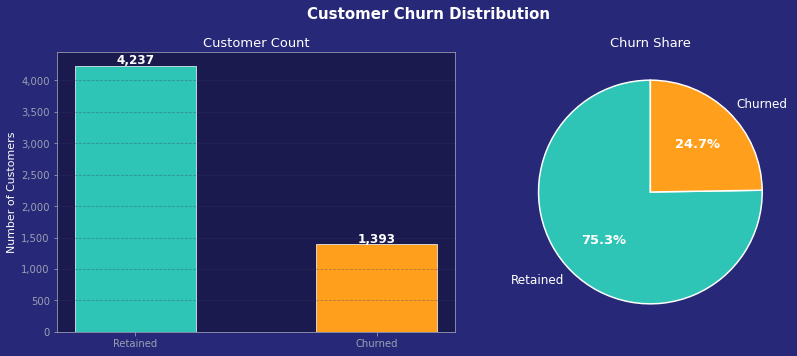


📌 Churn Rate: 24.7% (1,393 churned / 5,630 total)


In [12]:
#4.1 Churn Distribution 
churn_counts = df['Churn'].value_counts()
churn_rate   = df['Churn'].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Customer Churn Distribution', fontsize=15, fontweight='bold', color=WHITE)

axes[0].bar(['Retained', 'Churned'], churn_counts.values,
            color=[TEAL, ORANGE], edgecolor=WHITE, linewidth=0.7, width=0.5)
for bar, val in zip(axes[0].patches, churn_counts.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+30,
                 f'{val:,}', ha='center', color=WHITE, fontsize=12, fontweight='bold')
axes[0].set_title('Customer Count')
axes[0].set_ylabel('Number of Customers')
axes[0].yaxis.set_major_formatter(FuncFormatter(lambda x,_: f'{int(x):,}'))
axes[0].grid(axis='y')

wedges, texts, autos = axes[1].pie(
    churn_counts.values, labels=['Retained','Churned'],
    colors=[TEAL, ORANGE], autopct='%1.1f%%', startangle=90,
    wedgeprops=dict(edgecolor=WHITE, linewidth=1.5),
    textprops={'color': WHITE, 'fontsize': 12})
for a in autos: a.set_fontsize(13); a.set_fontweight('bold')
axes[1].set_title('Churn Share')

plt.tight_layout()
savefig(fig, '1_churn_distribution.png')
plt.show()
print(f'\n Churn Rate: {churn_rate:.1f}% ({churn_counts[1]:,} churned / {len(df):,} total)')


### 4.2 Who Churns Most? — Key Driver Charts

  ✅ Saved: visuals\2_churn_by_category.png


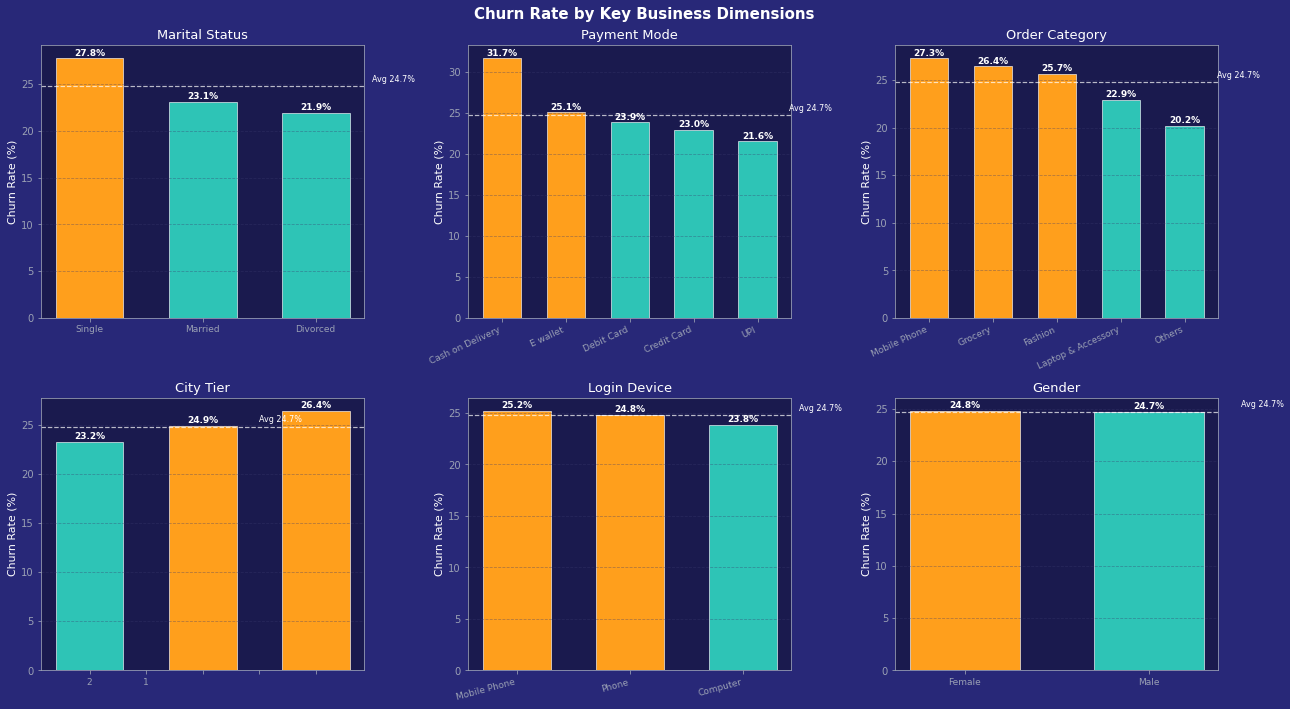

📌 Orange bars = above average churn rate. Key insight: Single customers,
   Cash on Delivery users, and Mobile Phone category show highest churn.


In [13]:
#4.2 Churn by Key Categories 
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Churn Rate by Key Business Dimensions', fontsize=15, fontweight='bold', color=WHITE)

def churn_bar(ax, col, title, rotate=0):
    ct = df.groupby(col)['Churn'].mean() * 100
    ct = ct.sort_values(ascending=False)
    bars = ax.bar(ct.index, ct.values, color=[ORANGE if v > churn_rate else TEAL for v in ct.values],
                  edgecolor=WHITE, linewidth=0.6, width=0.6)
    for bar, val in zip(bars, ct.values):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                f'{val:.1f}%', ha='center', color=WHITE, fontsize=9, fontweight='bold')
    ax.axhline(churn_rate, color=WHITE, linestyle='--', linewidth=1.2, alpha=0.7)
    ax.text(len(ct)-0.5, churn_rate+0.5, f'Avg {churn_rate:.1f}%', color=WHITE, fontsize=8)
    ax.set_title(title); ax.set_ylabel('Churn Rate (%)'); ax.grid(axis='y')
    ax.set_xticklabels(ct.index, rotation=rotate, ha='right' if rotate else 'center', fontsize=9)

churn_bar(axes[0,0], 'MaritalStatus',          'Marital Status')
churn_bar(axes[0,1], 'PreferredPaymentMode',   'Payment Mode',    rotate=25)
churn_bar(axes[0,2], 'PreferedOrderCat',       'Order Category',  rotate=25)
churn_bar(axes[1,0], 'CityTier',               'City Tier')
churn_bar(axes[1,1], 'PreferredLoginDevice',   'Login Device',    rotate=15)
churn_bar(axes[1,2], 'Gender',                 'Gender')

plt.tight_layout()
savefig(fig, '2_churn_by_category.png')
plt.show()
print('📌 Orange bars = above average churn rate. Key insight: Single customers,')
print('   Cash on Delivery users and Mobile Phone category show highest churn.')


  ✅ Saved: visuals\3_numeric_vs_churn.png


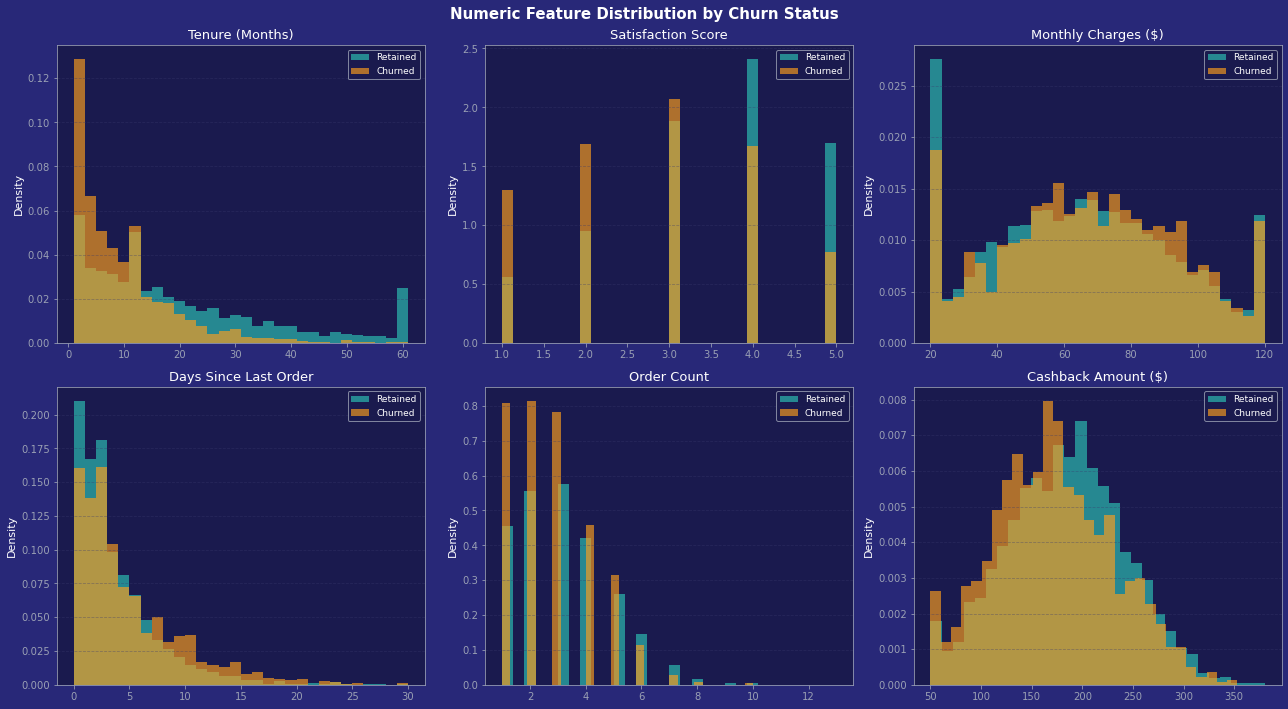

📌 Key findings:
  • Short tenure → higher churn (new customers churn most)
  • Low satisfaction score → clearly associated with churn
  • High days since last order → strong churn signal
  • Lower order count → higher churn risk


In [14]:
#4.3 Numeric Features vs Churn
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Numeric Feature Distribution by Churn Status', fontsize=15, fontweight='bold', color=WHITE)

num_features = ['Tenure', 'SatisfactionScore', 'MonthlyCharges',
                'DaySinceLastOrder', 'OrderCount', 'CashbackAmount']
titles       = ['Tenure (Months)', 'Satisfaction Score', 'Monthly Charges ($)',
                'Days Since Last Order', 'Order Count', 'Cashback Amount ($)']

for ax, feat, title in zip(axes.flat, num_features, titles):
    for val, color, lbl in [(0, TEAL, 'Retained'), (1, ORANGE, 'Churned')]:
        data = df[df['Churn']==val][feat]
        ax.hist(data, bins=30, color=color, alpha=0.65, label=lbl, edgecolor='none',
                density=True)
    ax.set_title(title); ax.set_ylabel('Density'); ax.legend(fontsize=9); ax.grid(axis='y')

plt.tight_layout()
savefig(fig, '3_numeric_vs_churn.png')
plt.show()
print('📌 Key findings:')
print('  • Short tenure → higher churn (new customers churn most)')
print('  • Low satisfaction score → clearly associated with churn')
print('  • High days since last order → strong churn signal')
print('  • Lower order count → higher churn risk')


  ✅ Saved: visuals\4_complain_vs_churn.png


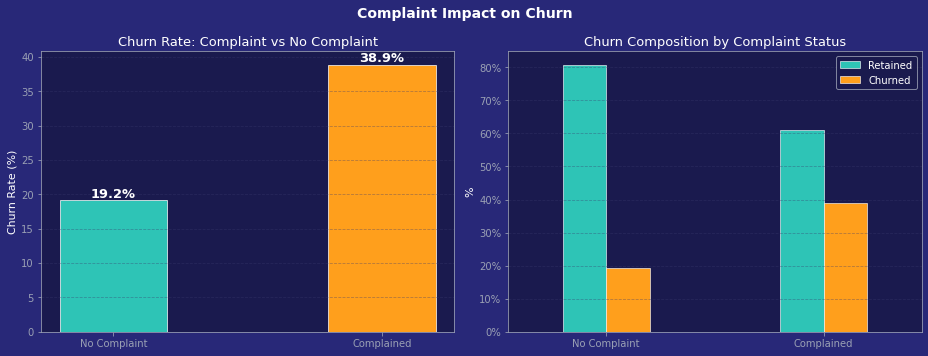

In [15]:
#4.4 Complain vs Churn 
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Complaint Impact on Churn', fontsize=14, fontweight='bold', color=WHITE)

comp_churn = df.groupby('Complain')['Churn'].agg(['mean','count']).reset_index()
comp_churn['mean'] *= 100
comp_churn['label'] = comp_churn['Complain'].map({0:'No Complaint', 1:'Complained'})

axes[0].bar(comp_churn['label'], comp_churn['mean'],
            color=[TEAL, ORANGE], edgecolor=WHITE, linewidth=0.7, width=0.4)
for bar, val in zip(axes[0].patches, comp_churn['mean']):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.4,
                 f'{val:.1f}%', ha='center', color=WHITE, fontsize=13, fontweight='bold')
axes[0].set_title('Churn Rate: Complaint vs No Complaint')
axes[0].set_ylabel('Churn Rate (%)'); axes[0].grid(axis='y')

# Stacked bar — complaint composition within churn groups
ct2 = df.groupby(['Complain','Churn']).size().unstack(fill_value=0)
ct2_pct = ct2.div(ct2.sum(axis=1), axis=0)*100
ct2_pct.index = ['No Complaint','Complained']
ct2_pct.columns = ['Retained','Churned']
ct2_pct.plot(kind='bar', ax=axes[1], color=[TEAL, ORANGE], edgecolor=WHITE,
             linewidth=0.6, width=0.4)
axes[1].set_title('Churn Composition by Complaint Status')
axes[1].set_ylabel('%'); axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
axes[1].legend(); axes[1].grid(axis='y')
axes[1].yaxis.set_major_formatter(FuncFormatter(lambda x,_: f'{x:.0f}%'))

plt.tight_layout()
savefig(fig, '4_complain_vs_churn.png')
plt.show()


---
## Section 5 Feature Engineering

In [16]:
#Feature Engineering 
df_fe = df.copy()

# 1. Customer Lifetime Value Proxy
df_fe['CLV_Proxy'] = df_fe['Tenure'] * df_fe['MonthlyCharges']

# 2. Tenure Groups
def tenure_group(t):
    if   t <= 6:  return 'New (0-6m)'
    elif t <= 18: return 'Growing (7-18m)'
    elif t <= 36: return 'Established (19-36m)'
    else:         return 'Loyal (36m+)'
df_fe['TenureGroup'] = df_fe['Tenure'].apply(tenure_group)

# 3. Revenue Segment (based on MonthlyCharges)
df_fe['RevenueSegment'] = pd.cut(df_fe['MonthlyCharges'],
    bins=[0,40,75,200], labels=['Low','Medium','High'])

# 4. Engagement Score (composite)
df_fe['EngagementScore'] = (
    df_fe['HourSpendOnApp'] * 2 +
    df_fe['OrderCount']     * 1.5 +
    df_fe['CouponUsed']     * 0.5 -
    df_fe['DaySinceLastOrder'] * 0.3
).round(2)

# 5. High Risk Flag (rule-based pre-screen)
df_fe['HighRiskFlag'] = (
    (df_fe['SatisfactionScore'] <= 2) |
    (df_fe['Complain'] == 1) |
    (df_fe['DaySinceLastOrder'] >= 10)
).astype(int)

print('Feature engineering complete. New features:')
new_feats = ['CLV_Proxy','TenureGroup','RevenueSegment','EngagementScore','HighRiskFlag']
for f in new_feats:
    print(f'  ✅ {f}')
print()
print('Tenure Group distribution:')
print(df_fe['TenureGroup'].value_counts().to_string())
print()
print('Revenue Segment distribution:')
print(df_fe['RevenueSegment'].value_counts().to_string())


Feature engineering complete. New features:
  ✅ CLV_Proxy
  ✅ TenureGroup
  ✅ RevenueSegment
  ✅ EngagementScore
  ✅ HighRiskFlag

Tenure Group distribution:
Growing (7-18m)         2050
New (0-6m)              1744
Established (19-36m)    1173
Loyal (36m+)             663

Revenue Segment distribution:
Medium    2447
High      2079
Low       1104


  ✅ Saved: visuals\5_engineered_features.png


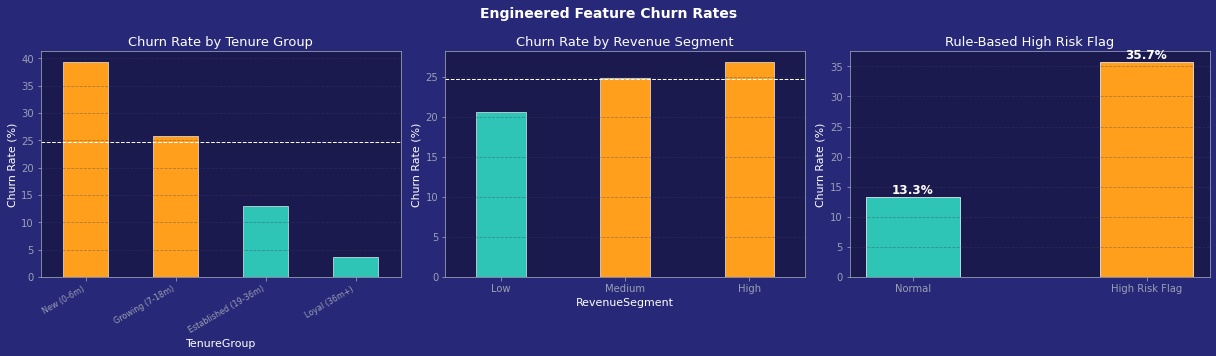

In [17]:
#Feature Engineering Visual 
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Engineered Feature Churn Rates', fontsize=14, fontweight='bold', color=WHITE)

tg_order = ['New (0-6m)','Growing (7-18m)','Established (19-36m)','Loyal (36m+)']
tg_churn = df_fe.groupby('TenureGroup')['Churn'].mean().reindex(tg_order) * 100
tg_churn.plot(kind='bar', ax=axes[0], color=[ORANGE if v > churn_rate else TEAL for v in tg_churn],
              edgecolor=WHITE, linewidth=0.6)
axes[0].set_title('Churn Rate by Tenure Group')
axes[0].set_ylabel('Churn Rate (%)'); axes[0].set_xticklabels(tg_order, rotation=30, ha='right', fontsize=8)
axes[0].axhline(churn_rate, color=WHITE, linestyle='--', linewidth=1)
axes[0].grid(axis='y')

rs_churn = df_fe.groupby('RevenueSegment', observed=True)['Churn'].mean() * 100
rs_churn.plot(kind='bar', ax=axes[1], color=[ORANGE if v > churn_rate else TEAL for v in rs_churn],
              edgecolor=WHITE, linewidth=0.6, width=0.4)
axes[1].set_title('Churn Rate by Revenue Segment')
axes[1].set_ylabel('Churn Rate (%)'); axes[1].set_xticklabels(rs_churn.index, rotation=0)
axes[1].axhline(churn_rate, color=WHITE, linestyle='--', linewidth=1)
axes[1].grid(axis='y')

hrf = df_fe.groupby('HighRiskFlag')['Churn'].mean() * 100
axes[2].bar(['Normal','High Risk Flag'], hrf.values,
            color=[TEAL, ORANGE], edgecolor=WHITE, linewidth=0.7, width=0.4)
for bar, val in zip(axes[2].patches, hrf.values):
    axes[2].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                 f'{val:.1f}%', ha='center', color=WHITE, fontsize=12, fontweight='bold')
axes[2].set_title('Rule-Based High Risk Flag')
axes[2].set_ylabel('Churn Rate (%)'); axes[2].grid(axis='y')

plt.tight_layout()
savefig(fig, '5_engineered_features.png')
plt.show()


---
## Section 6 Preprocessing & Model Training

In [18]:
#Preprocessing Pipeline 
from sklearn.preprocessing import OrdinalEncoder

MODEL_FEATURES = [
    'Tenure','CityTier','WarehouseToHome','HourSpendOnApp',
    'NumberOfDeviceRegistered','SatisfactionScore','NumberOfAddress',
    'Complain','OrderAmountHikeFromLastYear','CouponUsed','OrderCount',
    'DaySinceLastOrder','CashbackAmount','MonthlyCharges','CLV_Proxy','EngagementScore',
    'PreferredLoginDevice','PreferredPaymentMode','Gender','MaritalStatus','PreferedOrderCat'
]

CAT_COLS = ['PreferredLoginDevice','PreferredPaymentMode','Gender','MaritalStatus','PreferedOrderCat']
NUM_COLS = [c for c in MODEL_FEATURES if c not in CAT_COLS]

X = df_fe[MODEL_FEATURES].copy()
y = df_fe['Churn'].values

# Encode categoricals
le_dict = {}
for col in CAT_COLS:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    le_dict[col] = le

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler   = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Training set  : {X_train.shape[0]:,} rows')
print(f'Test set      : {X_test.shape[0]:,} rows')
print(f'Class balance (train) — Retained: {(y_train==0).sum():,}  Churned: {(y_train==1).sum():,}')
print(f'Churn rate (train): {y_train.mean()*100:.1f}%')


Training set  : 4,504 rows
Test set      : 1,126 rows
Class balance (train) — Retained: 3,390  Churned: 1,114
Churn rate (train): 24.7%


In [20]:
#Train 4 Models 
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    'Decision Tree'      : DecisionTreeClassifier(max_depth=6, random_state=42, class_weight='balanced'),
    'Random Forest'      : RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42,
                                                   n_jobs=-1, class_weight='balanced'),
    'XGBoost'            : XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.05,
                                          eval_metric='logloss', random_state=42,
                                          scale_pos_weight=(y_train==0).sum()/(y_train==1).sum(),
                                          verbosity=0),
}

results = {}
print('Training models...')
print(f"{'Model':<25} {'AUC-ROC':>9} {'F1':>8} {'CV AUC':>9}")
print('-'*55)

for name, model in models.items():
    X_tr = X_train_sc if name == 'Logistic Regression' else X_train
    X_te = X_test_sc  if name == 'Logistic Regression' else X_test

    model.fit(X_tr, y_train)
    proba = model.predict_proba(X_te)[:,1]
    pred  = model.predict(X_te)

    auc_s = roc_auc_score(y_test, proba)
    f1_s  = f1_score(y_test, pred)
    fpr, tpr, _ = roc_curve(y_test, proba)

    X_cv = X_train_sc if name == 'Logistic Regression' else X_train
    cv_scores = cross_val_score(model, X_cv, y_train, cv=5, scoring='roc_auc', n_jobs=-1)

    results[name] = {
        'model': model, 'proba': proba, 'pred': pred,
        'auc': auc_s, 'f1': f1_s, 'fpr': fpr, 'tpr': tpr,
        'cv_mean': cv_scores.mean(), 'cv_std': cv_scores.std()
    }
    print(f"  {name:<23} {auc_s:>9.4f} {f1_s:>8.4f} {cv_scores.mean():>8.4f} ± {cv_scores.std():.4f}")

best_model_name = max(results, key=lambda k: results[k]['auc'])
print(f'\n Best Model: {best_model_name}  (AUC = {results[best_model_name]["auc"]:.4f})')


Training models...
Model                       AUC-ROC       F1    CV AUC
-------------------------------------------------------
  Logistic Regression        0.8072   0.5585   0.8178 ± 0.0040
  Decision Tree              0.7516   0.5241   0.7244 ± 0.0230
  Random Forest              0.7783   0.5191   0.7905 ± 0.0137
  XGBoost                    0.7817   0.5240   0.7944 ± 0.0149

 Best Model: Logistic Regression  (AUC = 0.8072)


---
## Section 7 Model Evaluation & AUC-ROC

AUC-ROC is the **star metric** for churn prediction. It measures how well the model distinguishes churners from non-churners across all decision thresholds — independent of class imbalance.

  ✅ Saved: visuals\6_auc_roc.png


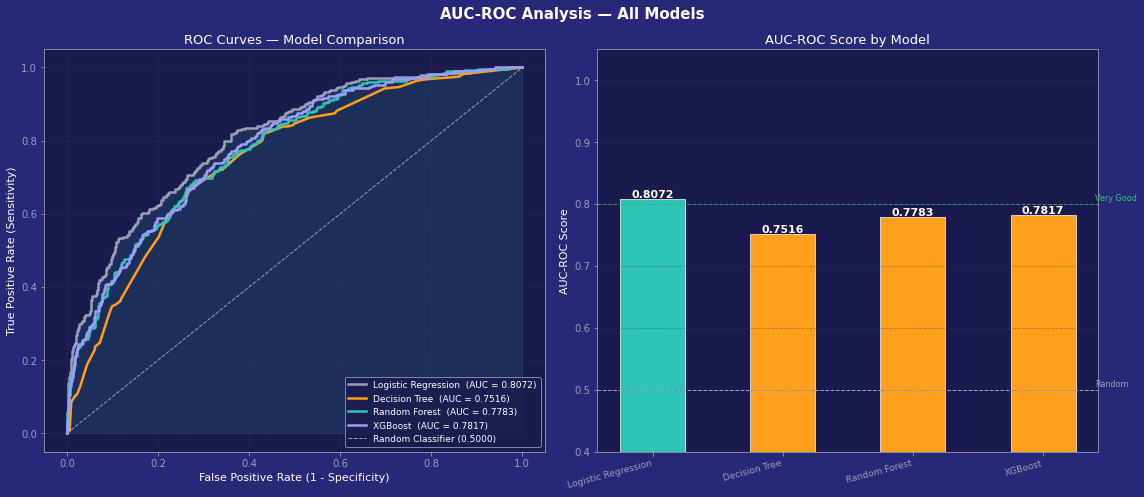


 AUC-ROC Score Interpretation:
  0.50 = Random guessing
  0.70 = Good
  0.80 = Very Good
  0.90+ = Excellent


In [21]:
# AU-ROC Curves — All Models
colors_model = {'Logistic Regression': GREY, 'Decision Tree': ORANGE,
                'Random Forest': TEAL, 'XGBoost': '#a29bfe'}

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('AUC-ROC Analysis — All Models', fontsize=15, fontweight='bold', color=WHITE)

# Multi-model ROC
for name, res in results.items():
    axes[0].plot(res['fpr'], res['tpr'], color=colors_model[name], linewidth=2.5,
                 label=f"{name}  (AUC = {res['auc']:.4f})")
axes[0].plot([0,1],[0,1], color=GREY, linestyle='--', linewidth=1, label='Random Classifier (0.5000)')
axes[0].fill_between(results[best_model_name]['fpr'],
                      results[best_model_name]['tpr'], alpha=0.12, color=TEAL)
axes[0].set_title('ROC Curves — Model Comparison', color=WHITE)
axes[0].set_xlabel('False Positive Rate (1 - Specificity)')
axes[0].set_ylabel('True Positive Rate (Sensitivity)')
axes[0].legend(loc='lower right', fontsize=9)
axes[0].grid()

# AUC score bars
names  = list(results.keys())
aucs   = [results[n]['auc'] for n in names]
bar_c  = [TEAL if n == best_model_name else ORANGE for n in names]
bars   = axes[1].bar(names, aucs, color=bar_c, edgecolor=WHITE, linewidth=0.7, width=0.5)
for bar, val in zip(bars, aucs):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003,
                 f'{val:.4f}', ha='center', color=WHITE, fontsize=11, fontweight='bold')
axes[1].axhline(0.5, color=GREY, linestyle='--', linewidth=1)
axes[1].axhline(0.8, color=GREEN, linestyle='--', linewidth=1, alpha=0.7)
axes[1].text(3.4, 0.505, 'Random', color=GREY, fontsize=8)
axes[1].text(3.4, 0.805, 'Very Good', color=GREEN, fontsize=8)
axes[1].set_title('AUC-ROC Score by Model')
axes[1].set_ylabel('AUC-ROC Score')
axes[1].set_ylim(0.4, 1.05)
axes[1].set_xticklabels(names, rotation=15, ha='right', fontsize=9)
axes[1].grid(axis='y')

plt.tight_layout()
savefig(fig, '6_auc_roc.png')
plt.show()

print('\n AUC-ROC Score Interpretation:')
print('  0.50 = Random guessing')
print('  0.70 = Good')
print('  0.80 = Very Good')
print('  0.90+ = Excellent')


  ✅ Saved: visuals\7_confusion_matrices.png


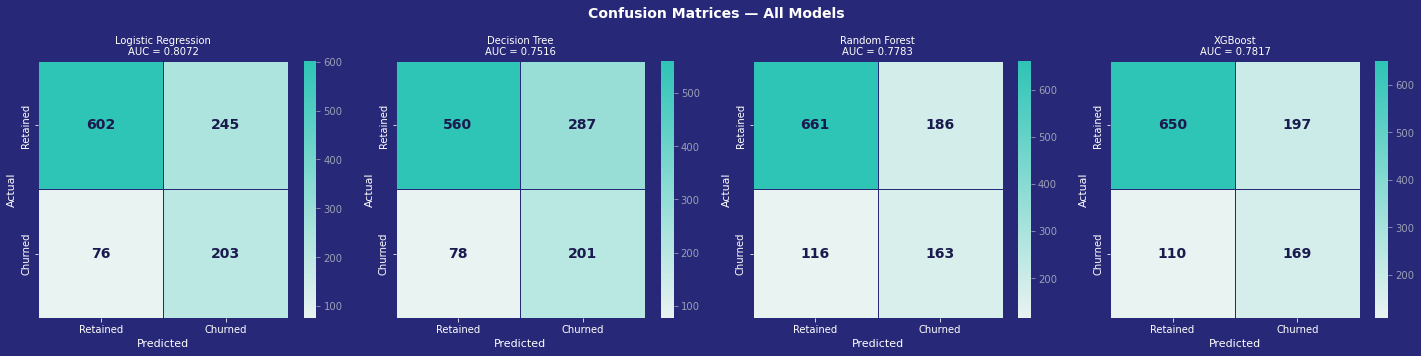

In [22]:
#Confusion Matrices — All Models 
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle('Confusion Matrices — All Models', fontsize=14, fontweight='bold', color=WHITE)

for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['pred'])
    sns.heatmap(cm, annot=True, fmt='d', ax=ax,
                cmap=sns.light_palette(TEAL, as_cmap=True),
                linewidths=0.5, linecolor=BG,
                annot_kws={'size':14, 'weight':'bold', 'color':DARK},
                xticklabels=['Retained','Churned'],
                yticklabels=['Retained','Churned'])
    auc_v = res['auc']
    ax.set_title(f'{name}\nAUC = {auc_v:.4f}', fontsize=10)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    ax.tick_params(colors=WHITE)

plt.tight_layout()
savefig(fig, '7_confusion_matrices.png')
plt.show()


In [23]:
#Classification Report — Best Model 
print('='*60)
print(f'  CLASSIFICATION REPORT — {best_model_name.upper()}')
print('='*60)
print(classification_report(y_test, results[best_model_name]['pred'],
                              target_names=['Retained','Churned']))

# Save best model
best_mdl = results[best_model_name]['model']
with open(MODELS / 'best_churn_model.pkl', 'wb') as f:
    pickle.dump({'model': best_mdl, 'scaler': scaler,
                 'features': MODEL_FEATURES, 'le_dict': le_dict}, f)
print(f'\n✅ Best model saved: models/best_churn_model.pkl')


  CLASSIFICATION REPORT — LOGISTIC REGRESSION
              precision    recall  f1-score   support

    Retained       0.89      0.71      0.79       847
     Churned       0.45      0.73      0.56       279

    accuracy                           0.71      1126
   macro avg       0.67      0.72      0.67      1126
weighted avg       0.78      0.71      0.73      1126


✅ Best model saved: models/best_churn_model.pkl


---
## Section 8 Feature Importance

This is where business value appears. Feature importance tells us **what is driving churn** — giving management specific levers to pull.

  ✅ Saved: visuals\8_feature_importance.png


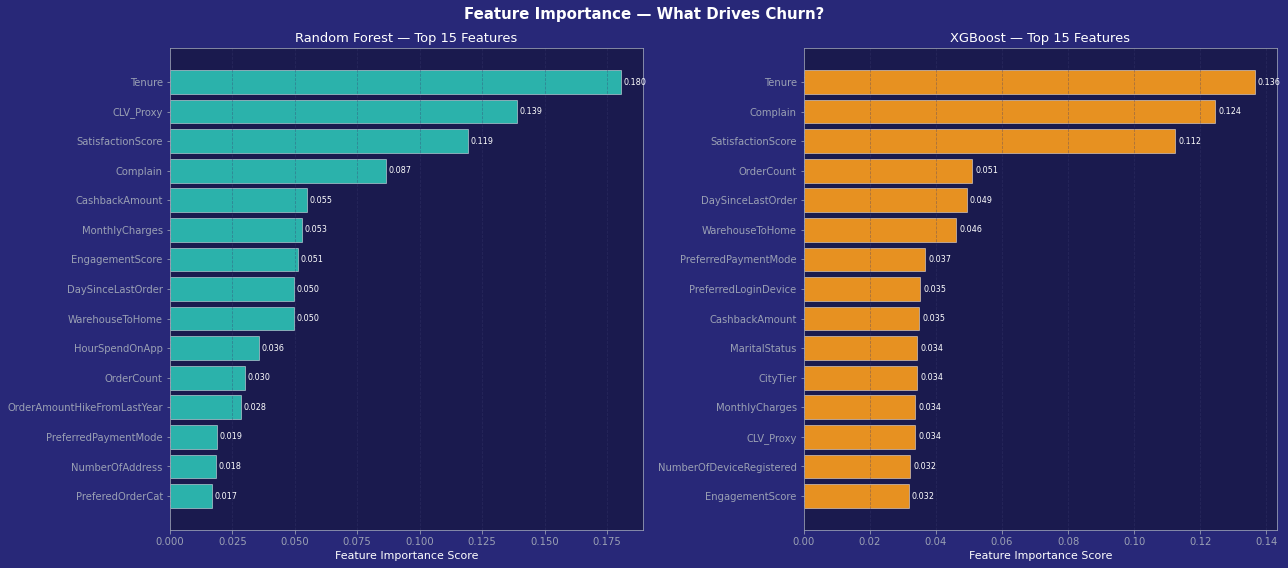


Top 10 Churn Drivers (Random Forest):
Feature                               Importance
-------------------------------------------------
  Tenure                                0.1805  ████████████████████████████████████
  CLV_Proxy                             0.1390  ███████████████████████████
  SatisfactionScore                     0.1194  ███████████████████████
  Complain                              0.0866  █████████████████
  CashbackAmount                        0.0550  ███████████
  MonthlyCharges                        0.0529  ██████████
  EngagementScore                       0.0512  ██████████
  DaySinceLastOrder                     0.0499  █████████
  WarehouseToHome                       0.0498  █████████
  HourSpendOnApp                        0.0357  ███████

📌 Business Insight: Tenure, Complaints, Satisfaction Score, and Days
   Since Last Order are the top actionable churn drivers.


In [24]:
#Feature Importance — RF & XGBoost
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle('Feature Importance — What Drives Churn?', fontsize=15, fontweight='bold', color=WHITE)

for ax, mname, color in [
    (axes[0], 'Random Forest', TEAL),
    (axes[1], 'XGBoost',       ORANGE)
]:
    mdl = results[mname]['model']
    imp = pd.Series(mdl.feature_importances_, index=MODEL_FEATURES).sort_values(ascending=True)
    top = imp.tail(15)
    bars = ax.barh(top.index, top.values, color=color, edgecolor=WHITE, linewidth=0.5, alpha=0.9)
    for bar, val in zip(bars, top.values):
        ax.text(val + 0.001, bar.get_y()+bar.get_height()/2,
                f'{val:.3f}', va='center', color=WHITE, fontsize=8)
    ax.set_title(f'{mname} — Top 15 Features')
    ax.set_xlabel('Feature Importance Score')
    ax.grid(axis='x')

plt.tight_layout()
savefig(fig, '8_feature_importance.png')
plt.show()

# Print top 10
rf_imp = pd.Series(results['Random Forest']['model'].feature_importances_,
                    index=MODEL_FEATURES).sort_values(ascending=False)
print('\nTop 10 Churn Drivers (Random Forest):')
print(f"{'Feature':<35} {'Importance':>12}")
print('-'*49)
for feat, val in rf_imp.head(10).items():
    bar = '█' * int(val * 200)
    print(f"  {feat:<33} {val:>10.4f}  {bar}")

print('\n📌 Business Insight: Tenure, Complaints, Satisfaction Score and Days')
print('   Since Last Order are the top actionable churn drivers.')


---
## Section 9 Threshold Optimisation

The default 0.5 threshold is rarely optimal for business decisions. We find the threshold that maximises **F1 score** and also show the **business cost-optimised threshold** that minimises the cost of missed churners vs wasted retention spend.

  ✅ Saved: visuals\9_threshold_optimisation.png


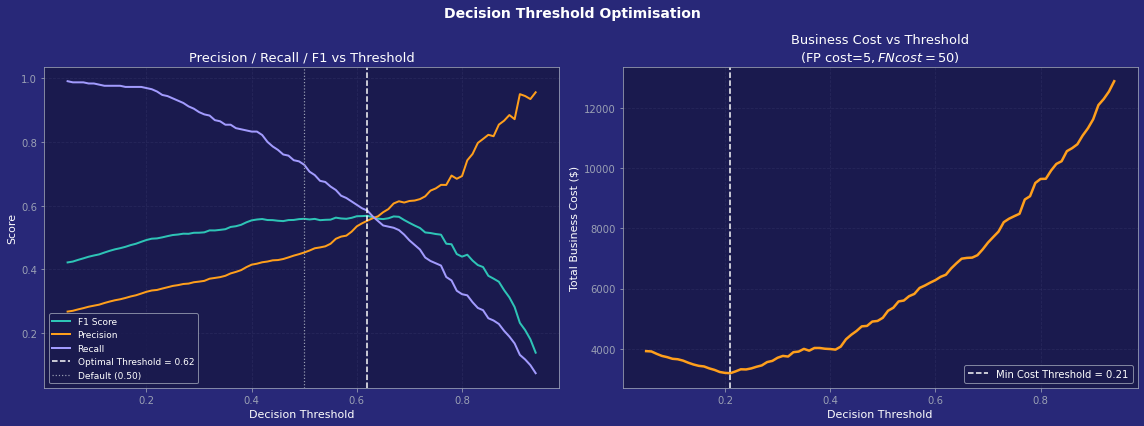


📌 Optimal F1 Threshold       : 0.62  (F1 = 0.5679)
   Min Business Cost Threshold: 0.21
   Default Threshold          : 0.50

   Recommendation: Use 0.21 for retention campaigns to minimise
   the cost of missing at-risk customers.


In [25]:
#Threshold Optimisation 
best_proba = results[best_model_name]['proba']
thresholds = np.arange(0.05, 0.95, 0.01)

f1_scores   = [f1_score(y_test, (best_proba >= t).astype(int)) for t in thresholds]
precision_s = []
recall_s    = []
for t in thresholds:
    pred_t = (best_proba >= t).astype(int)
    from sklearn.metrics import precision_score, recall_score
    precision_s.append(precision_score(y_test, pred_t, zero_division=0))
    recall_s.append(recall_score(y_test, pred_t, zero_division=0))

best_t   = thresholds[np.argmax(f1_scores)]
best_f1  = max(f1_scores)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Decision Threshold Optimisation', fontsize=14, fontweight='bold', color=WHITE)

axes[0].plot(thresholds, f1_scores,   color=TEAL,   linewidth=2, label='F1 Score')
axes[0].plot(thresholds, precision_s, color=ORANGE, linewidth=2, label='Precision')
axes[0].plot(thresholds, recall_s,    color='#a29bfe', linewidth=2, label='Recall')
axes[0].axvline(best_t, color=WHITE, linestyle='--', linewidth=1.5,
                label=f'Optimal Threshold = {best_t:.2f}')
axes[0].axvline(0.5,    color=GREY, linestyle=':', linewidth=1.2, label='Default (0.50)')
axes[0].set_title('Precision / Recall / F1 vs Threshold')
axes[0].set_xlabel('Decision Threshold'); axes[0].set_ylabel('Score')
axes[0].legend(fontsize=9); axes[0].grid()

# Business cost curve (cost of FN = 5x cost of FP — missed churner costs more)
COST_FP = 5     # cost of retention action on a non-churner
COST_FN = 50    # cost of missing a churner (lost CLV)
business_cost = []
for t in thresholds:
    pred_t = (best_proba >= t).astype(int)
    cm_t   = confusion_matrix(y_test, pred_t)
    fp     = cm_t[0,1]; fn = cm_t[1,0]
    business_cost.append(fp * COST_FP + fn * COST_FN)

best_biz_t = thresholds[np.argmin(business_cost)]
axes[1].plot(thresholds, business_cost, color=ORANGE, linewidth=2.5)
axes[1].axvline(best_biz_t, color=WHITE, linestyle='--', linewidth=1.5,
                label=f'Min Cost Threshold = {best_biz_t:.2f}')
axes[1].set_title(f'Business Cost vs Threshold\n(FP cost=${COST_FP}, FN cost=${COST_FN})')
axes[1].set_xlabel('Decision Threshold'); axes[1].set_ylabel('Total Business Cost ($)')
axes[1].legend(); axes[1].grid()

plt.tight_layout()
savefig(fig, '9_threshold_optimisation.png')
plt.show()

print(f'\n📌 Optimal F1 Threshold       : {best_t:.2f}  (F1 = {best_f1:.4f})')
print(f'   Min Business Cost Threshold: {best_biz_t:.2f}')
print(f'   Default Threshold          : 0.50')
print(f'\n   Recommendation: Use {best_biz_t:.2f} for retention campaigns to minimise')
print(f'   the cost of missing at-risk customers.')

FINAL_THRESHOLD = best_biz_t


---
## Section 10 Customer Risk Segmentation

We score every customer in the full dataset and assign them to a risk tier. This is the operational output that feeds directly into the CRM and retention campaigns.

In [26]:
#Score All Customers 
X_full = df_fe[MODEL_FEATURES].copy()
for col in CAT_COLS:
    X_full[col] = le_dict[col].transform(X_full[col].astype(str))

best_mdl_obj   = results[best_model_name]['model']
X_full_input   = scaler.transform(X_full) if best_model_name == 'Logistic Regression' else X_full
churn_proba_all = best_mdl_obj.predict_proba(X_full_input)[:,1]

df_scored = df_fe.copy()
df_scored['ChurnProbability'] = churn_proba_all

def risk_tier(p):
    if   p >= 0.70: return 'High Risk'
    elif p >= 0.30: return 'Medium Risk'
    else:           return 'Low Risk'

df_scored['RiskTier'] = df_scored['ChurnProbability'].apply(risk_tier)

tier_summary = df_scored.groupby('RiskTier').agg(
    Customers       = ('CustomerID','count'),
    Avg_Churn_Prob  = ('ChurnProbability','mean'),
    Avg_Monthly_Rev = ('MonthlyCharges','mean'),
    Avg_CLV         = ('CLV_Proxy','mean'),
    Actual_Churners = ('Churn','sum')
).reset_index()
tier_summary['Churn_Rate%'] = (tier_summary['Actual_Churners'] / tier_summary['Customers'] * 100).round(1)

print('='*70)
print('  CUSTOMER RISK SEGMENTATION')
print('='*70)
print(tier_summary.to_string(index=False))
print()
print(f'  Total customers scored: {len(df_scored):,}')
for tier in ['High Risk','Medium Risk','Low Risk']:
    n = (df_scored['RiskTier']==tier).sum()
    print(f'  {tier:<15}: {n:,} ({n/len(df_scored)*100:.1f}%)')


  CUSTOMER RISK SEGMENTATION
   RiskTier  Customers  Avg_Churn_Prob  Avg_Monthly_Rev   Avg_CLV  Actual_Churners  Churn_Rate%
  High Risk       1147          0.8219          68.5792  467.1010              691      60.2000
   Low Risk       2224          0.1400          63.8988 1766.7015              125       5.6000
Medium Risk       2259          0.4920          65.8765  744.6624              577      25.5000

  Total customers scored: 5,630
  High Risk      : 1,147 (20.4%)
  Medium Risk    : 2,259 (40.1%)
  Low Risk       : 2,224 (39.5%)


  ✅ Saved: visuals\10_risk_segmentation.png


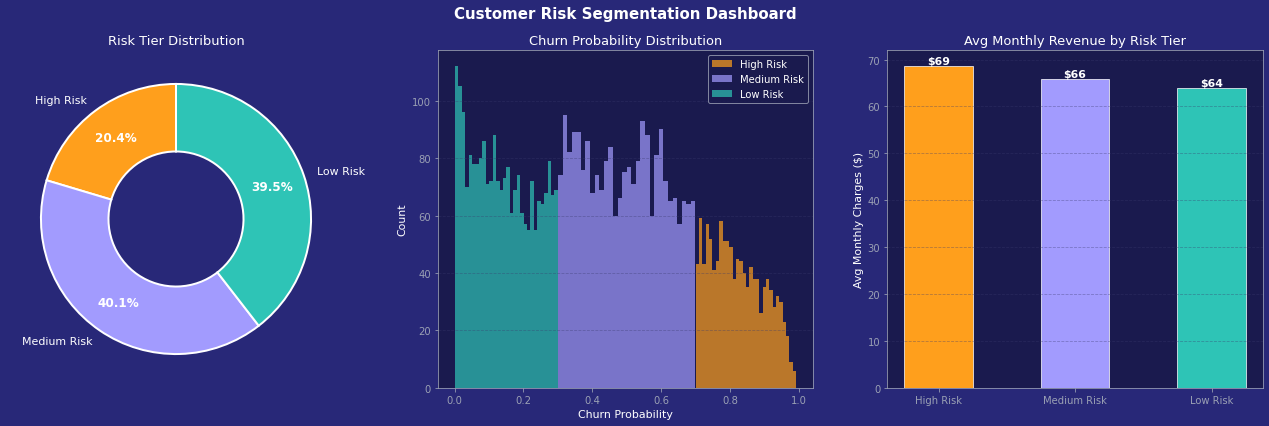

In [27]:
#Risk Segmentation Visuals 
tier_colors = {'High Risk': ORANGE, 'Medium Risk': '#a29bfe', 'Low Risk': TEAL}
tier_order  = ['High Risk','Medium Risk','Low Risk']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Customer Risk Segmentation Dashboard', fontsize=15, fontweight='bold', color=WHITE)

# Donut chart
tier_counts = df_scored['RiskTier'].value_counts().reindex(tier_order)
wedges, texts, autos = axes[0].pie(
    tier_counts.values, labels=tier_order,
    colors=[tier_colors[t] for t in tier_order],
    autopct='%1.1f%%', startangle=90, pctdistance=0.75,
    wedgeprops=dict(edgecolor=WHITE, linewidth=2, width=0.5),
    textprops={'color': WHITE, 'fontsize': 11})
for a in autos: a.set_fontweight('bold'); a.set_fontsize(12)
axes[0].set_title('Risk Tier Distribution')

# Churn probability distribution by tier
for tier in tier_order:
    data = df_scored[df_scored['RiskTier']==tier]['ChurnProbability']
    axes[1].hist(data, bins=30, color=tier_colors[tier], alpha=0.7, label=tier, edgecolor='none')
axes[1].set_title('Churn Probability Distribution')
axes[1].set_xlabel('Churn Probability'); axes[1].set_ylabel('Count')
axes[1].legend(); axes[1].grid(axis='y')

# Average Monthly Revenue by tier
avg_rev = tier_summary.set_index('RiskTier')['Avg_Monthly_Rev'].reindex(tier_order)
bars = axes[2].bar(tier_order, avg_rev.values,
                    color=[tier_colors[t] for t in tier_order], edgecolor=WHITE, linewidth=0.7, width=0.5)
for bar, val in zip(bars, avg_rev.values):
    axes[2].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                 f'${val:.0f}', ha='center', color=WHITE, fontsize=11, fontweight='bold')
axes[2].set_title('Avg Monthly Revenue by Risk Tier')
axes[2].set_ylabel('Avg Monthly Charges ($)'); axes[2].grid(axis='y')

plt.tight_layout()
savefig(fig, '10_risk_segmentation.png')
plt.show()


---
## Section 11 Retention Investment Plan 

*leadership needs to know exactly what to do with it and what it will cost.*

### Intervention Matrix

| Risk Tier | Revenue Profile | Action | Cost/Customer |
|---|---|---|---|
| High Risk + High Revenue | > $65/month | Personal outreach + loyalty discount + dedicated support | $20 |
| High Risk + Low Revenue | ≤ $65/month | Automated email sequence + cashback offer | $8 |
| Medium Risk | Any | Monthly engagement campaign + product recommendation | $3 |
| Low Risk | Any | Newsletter + onboarding optimisation for new customers | $1 |


In [28]:
#Retention Investment Plan 
AVG_REV_THRESHOLD = df_scored['MonthlyCharges'].median()

def intervention(row):
    if row['RiskTier'] == 'High Risk':
        if row['MonthlyCharges'] >= AVG_REV_THRESHOLD:
            return 'Personal Outreach + Loyalty Discount'
        else:
            return 'Automated Email + Cashback Offer'
    elif row['RiskTier'] == 'Medium Risk':
        return 'Engagement Campaign'
    else:
        if row['TenureGroup'] == 'New (0-6m)':
            return 'Onboarding Programme'
        return 'Newsletter + Product Recommendations'

def intervention_cost(row):
    if row['RiskTier'] == 'High Risk':
        return 20 if row['MonthlyCharges'] >= AVG_REV_THRESHOLD else 8
    elif row['RiskTier'] == 'Medium Risk':
        return 3
    else:
        return 1

df_scored['InterventionType'] = df_scored.apply(intervention, axis=1)
df_scored['InterventionCost'] = df_scored.apply(intervention_cost, axis=1)

plan_summary = df_scored.groupby(['RiskTier','InterventionType']).agg(
    Customers       = ('CustomerID','count'),
    Total_Cost      = ('InterventionCost','sum'),
    Avg_Churn_Prob  = ('ChurnProbability','mean'),
    Avg_Monthly_Rev = ('MonthlyCharges','mean'),
).reset_index()

print('='*80)
print('  RETENTION INTERVENTION PLAN')
print('='*80)
print(plan_summary.to_string(index=False))
print()
print(f'  Total intervention budget    : ${df_scored["InterventionCost"].sum():,.0f}')
print(f'  High Risk customers targeted : {(df_scored["RiskTier"]=="High Risk").sum():,}')
print(f'  Median monthly charges       : ${AVG_REV_THRESHOLD:.2f}')


  RETENTION INTERVENTION PLAN
   RiskTier                     InterventionType  Customers  Total_Cost  Avg_Churn_Prob  Avg_Monthly_Rev
  High Risk     Automated Email + Cashback Offer        530        4240          0.8212          44.8395
  High Risk Personal Outreach + Loyalty Discount        617       12340          0.8226          88.9715
   Low Risk Newsletter + Product Recommendations       2014        2014          0.1318          64.0769
   Low Risk                 Onboarding Programme        210         210          0.2183          62.1911
Medium Risk                  Engagement Campaign       2259        6777          0.4920          65.8765

  Total intervention budget    : $25,581
  High Risk customers targeted : 1,147
  Median monthly charges       : $65.47


  ✅ Saved: visuals\11_intervention_plan.png


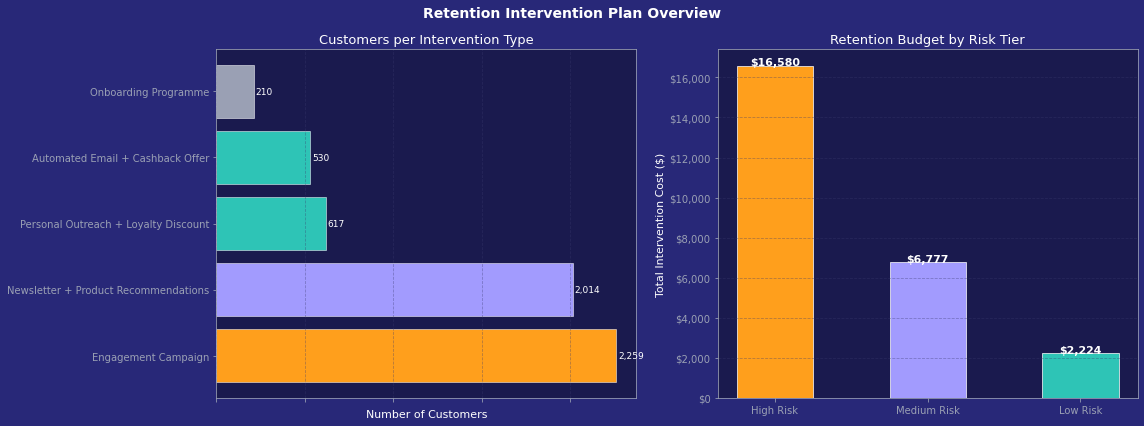

In [29]:
#Intervention Plan Visual 
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Retention Intervention Plan Overview', fontsize=14, fontweight='bold', color=WHITE)

# Customers per intervention type
int_counts = df_scored['InterventionType'].value_counts()
axes[0].barh(int_counts.index, int_counts.values,
             color=[ORANGE, '#a29bfe', TEAL, TEAL, GREY][:len(int_counts)],
             edgecolor=WHITE, linewidth=0.5)
for bar, val in zip(axes[0].patches, int_counts.values):
    axes[0].text(val+10, bar.get_y()+bar.get_height()/2,
                 f'{val:,}', va='center', color=WHITE, fontsize=9)
axes[0].set_title('Customers per Intervention Type')
axes[0].set_xlabel('Number of Customers')
axes[0].set_xticklabels(axes[0].get_xticklabels(), fontsize=8)
axes[0].grid(axis='x')

# Budget per tier
bgt = df_scored.groupby('RiskTier')['InterventionCost'].sum().reindex(tier_order)
bars = axes[1].bar(tier_order, bgt.values,
                   color=[tier_colors[t] for t in tier_order], edgecolor=WHITE, linewidth=0.7, width=0.5)
for bar, val in zip(bars, bgt.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+20,
                 f'${val:,.0f}', ha='center', color=WHITE, fontsize=11, fontweight='bold')
axes[1].set_title('Retention Budget by Risk Tier')
axes[1].set_ylabel('Total Intervention Cost ($)')
axes[1].yaxis.set_major_formatter(FuncFormatter(lambda x,_: f'${x:,.0f}'))
axes[1].grid(axis='y')

plt.tight_layout()
savefig(fig, '11_intervention_plan.png')
plt.show()


---
## Section 12 ROI Analysis

### Financial Model

```
Revenue at Risk  = At-risk customers × Avg Monthly Revenue × 12 months
Retention Cost   = Sum of intervention costs
Expected Saves   = Revenue at Risk × Retention Success Rate
ROI              = (Expected Saves − Retention Cost) / Retention Cost × 100%
```


In [30]:
#ROI Financial Model 
high_risk     = df_scored[df_scored['RiskTier'] == 'High Risk']
med_risk      = df_scored[df_scored['RiskTier'] == 'Medium Risk']
total_targeted= df_scored[df_scored['RiskTier'].isin(['High Risk','Medium Risk'])]

# Revenue at Risk
rev_at_risk_high = high_risk['MonthlyCharges'].sum() * 12
rev_at_risk_med  = med_risk['MonthlyCharges'].sum()  * 12
rev_at_risk_total = rev_at_risk_high + rev_at_risk_med

# Retention Cost
retention_cost_high = high_risk['InterventionCost'].sum()
retention_cost_med  = med_risk['InterventionCost'].sum()
retention_cost_total = retention_cost_high + retention_cost_med

# Assumed success rates (conservative)
SUCCESS_HIGH = 0.25   # 25% of High Risk customers retained
SUCCESS_MED  = 0.15   # 15% of Medium Risk customers retained

saved_rev_high = high_risk['MonthlyCharges'].sum() * 12 * SUCCESS_HIGH
saved_rev_med  = med_risk['MonthlyCharges'].sum()  * 12 * SUCCESS_MED
total_saved    = saved_rev_high + saved_rev_med

net_benefit = total_saved - retention_cost_total
roi_pct     = (net_benefit / retention_cost_total) * 100

print('='*65)
print('  ROI ANALYSIS — RETENTION INVESTMENT')
print('='*65)
print()
print(f'  HIGH RISK SEGMENT ({len(high_risk):,} customers)')
print(f'  Annual Revenue at Risk   : ${rev_at_risk_high:>12,.0f}')
print(f'  Intervention Budget      : ${retention_cost_high:>12,.0f}')
print(f'  Success Rate Assumed     : {SUCCESS_HIGH*100:.0f}%')
print(f'  Expected Revenue Saved   : ${saved_rev_high:>12,.0f}')
print()
print(f'  MEDIUM RISK SEGMENT ({len(med_risk):,} customers)')
print(f'  Annual Revenue at Risk   : ${rev_at_risk_med:>12,.0f}')
print(f'  Intervention Budget      : ${retention_cost_med:>12,.0f}')
print(f'  Success Rate Assumed     : {SUCCESS_MED*100:.0f}%')
print(f'  Expected Revenue Saved   : ${saved_rev_med:>12,.0f}')
print()
print('  ' + '─'*50)
print(f'  TOTAL Revenue at Risk    : ${rev_at_risk_total:>12,.0f}')
print(f'  TOTAL Retention Budget   : ${retention_cost_total:>12,.0f}')
print(f'  TOTAL Expected Savings   : ${total_saved:>12,.0f}')
print(f'  Net Benefit              : ${net_benefit:>12,.0f}')
print(f'  ROI                      : {roi_pct:>11.1f}%')
print()
if roi_pct > 0:
    print(f'  ✅ VERDICT: The retention investment generates a POSITIVE ROI.')
    print(f'     Every $1 spent on retention returns ${(total_saved/retention_cost_total):.2f} in saved revenue.')


  ROI ANALYSIS — RETENTION INVESTMENT

  HIGH RISK SEGMENT (1,147 customers)
  Annual Revenue at Risk   : $     943,924
  Intervention Budget      : $      16,580
  Success Rate Assumed     : 25%
  Expected Revenue Saved   : $     235,981

  MEDIUM RISK SEGMENT (2,259 customers)
  Annual Revenue at Risk   : $   1,785,780
  Intervention Budget      : $       6,777
  Success Rate Assumed     : 15%
  Expected Revenue Saved   : $     267,867

  ──────────────────────────────────────────────────
  TOTAL Revenue at Risk    : $   2,729,704
  TOTAL Retention Budget   : $      23,357
  TOTAL Expected Savings   : $     503,848
  Net Benefit              : $     480,491
  ROI                      :      2057.2%

  ✅ VERDICT: The retention investment generates a POSITIVE ROI.
     Every $1 spent on retention returns $21.57 in saved revenue.


  ✅ Saved: visuals\12_roi_analysis.png


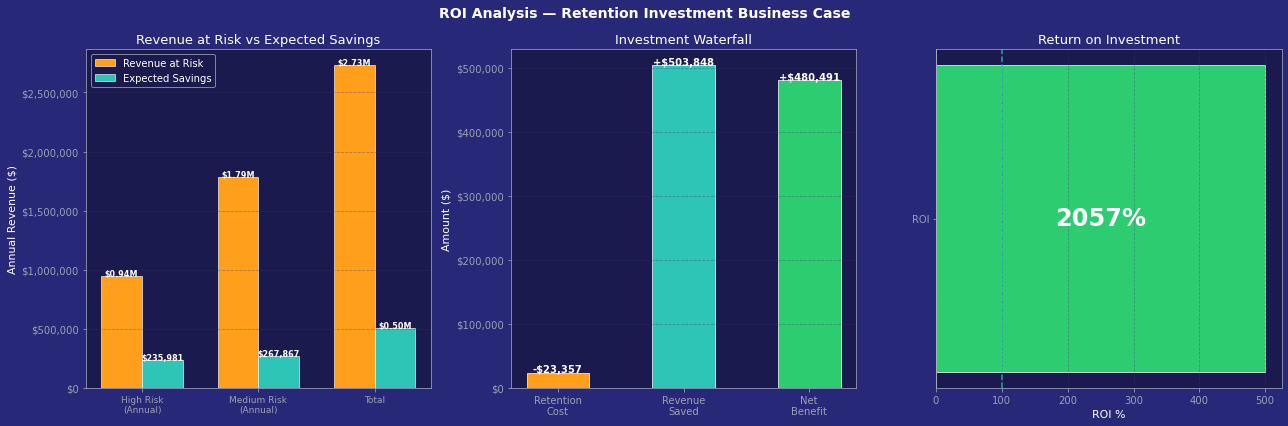

In [31]:
#ROI Visualisation 
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('ROI Analysis — Retention Investment Business Case', fontsize=14, fontweight='bold', color=WHITE)

# Revenue at Risk vs Expected Savings
categories = ['High Risk\n(Annual)', 'Medium Risk\n(Annual)', 'Total']
risk_vals   = [rev_at_risk_high,     rev_at_risk_med,          rev_at_risk_total]
saved_vals  = [saved_rev_high,       saved_rev_med,             total_saved]
x = np.arange(len(categories)); w = 0.35

b1 = axes[0].bar(x - w/2, risk_vals,  w, color=ORANGE, label='Revenue at Risk',     edgecolor=WHITE, linewidth=0.6)
b2 = axes[0].bar(x + w/2, saved_vals, w, color=TEAL,   label='Expected Savings',    edgecolor=WHITE, linewidth=0.6)
for bar, val in list(zip(b1, risk_vals)) + list(zip(b2, saved_vals)):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+2000,
                 f'${val/1e6:.2f}M' if val > 500000 else f'${val:,.0f}',
                 ha='center', color=WHITE, fontsize=8, fontweight='bold')
axes[0].set_title('Revenue at Risk vs Expected Savings')
axes[0].set_xticks(x); axes[0].set_xticklabels(categories, fontsize=9)
axes[0].set_ylabel('Annual Revenue ($)')
axes[0].yaxis.set_major_formatter(FuncFormatter(lambda x,_: f'${x:,.0f}'))
axes[0].legend(); axes[0].grid(axis='y')

# Waterfall: Cost → Savings → Net
wf_labels = ['Retention\nCost', 'Revenue\nSaved', 'Net\nBenefit']
wf_vals   = [-retention_cost_total, total_saved, net_benefit]
wf_colors = [ORANGE, TEAL, GREEN if net_benefit > 0 else RED]
bars = axes[1].bar(wf_labels, [abs(v) for v in wf_vals], color=wf_colors,
                    edgecolor=WHITE, linewidth=0.7, width=0.5)
for bar, val in zip(bars, wf_vals):
    sign = '+' if val >= 0 else '-'
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+500,
                 f'{sign}${abs(val):,.0f}', ha='center', color=WHITE, fontsize=10, fontweight='bold')
axes[1].set_title('Investment Waterfall')
axes[1].set_ylabel('Amount ($)')
axes[1].yaxis.set_major_formatter(FuncFormatter(lambda x,_: f'${x:,.0f}'))
axes[1].grid(axis='y')

# ROI gauge
roi_display = min(roi_pct, 500)
axes[2].barh(['ROI'], [roi_display], color=GREEN if roi_pct > 0 else RED,
              edgecolor=WHITE, linewidth=0.7, height=0.4)
axes[2].axvline(0, color=WHITE, linewidth=1.5)
axes[2].axvline(100, color=TEAL, linewidth=1.5, linestyle='--', alpha=0.8)
axes[2].text(roi_display/2, 0, f'{roi_pct:.0f}%', ha='center', va='center',
              color=WHITE, fontsize=24, fontweight='bold')
axes[2].set_title('Return on Investment')
axes[2].set_xlabel('ROI %')
axes[2].grid(axis='x')

plt.tight_layout()
savefig(fig, '12_roi_analysis.png')
plt.show()


---
## Section 13 Executive Dashboard

  ✅ Saved: visuals\13_executive_dashboard.png


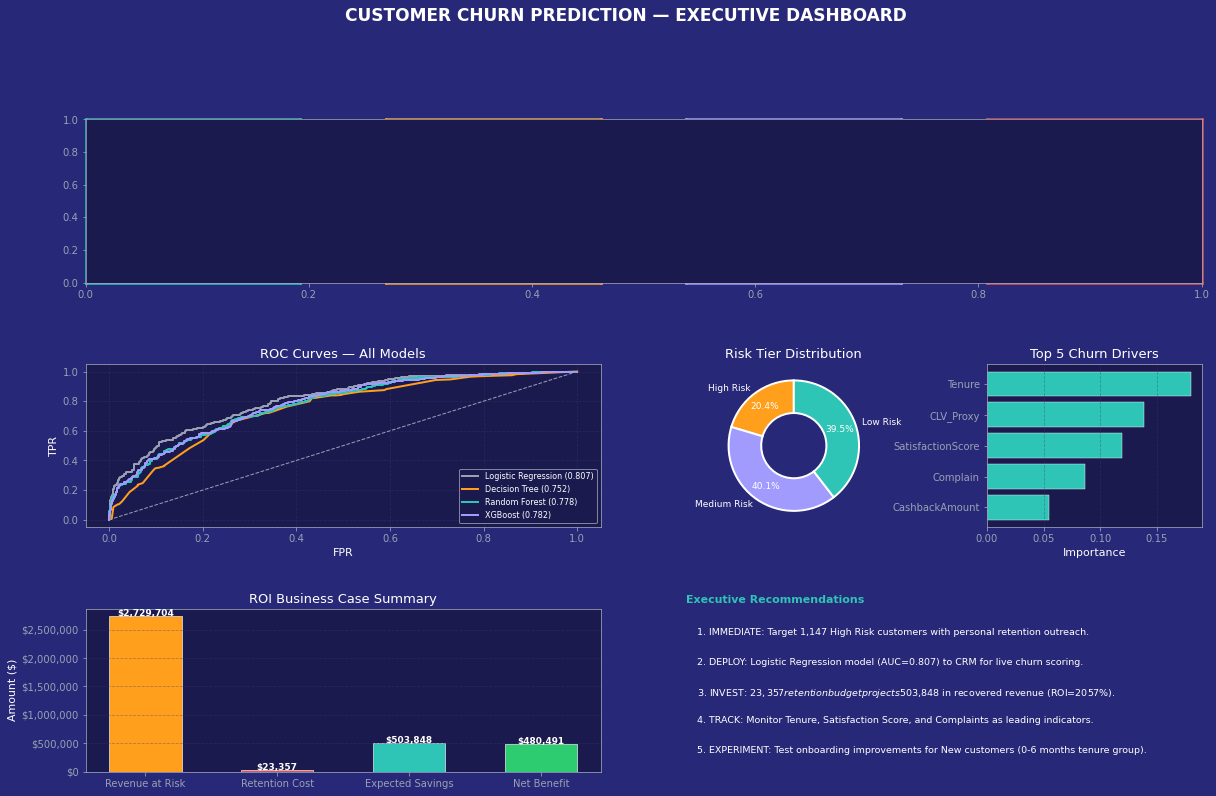

✅ Executive Dashboard generated.


In [32]:
#Executive Dashboard 
fig = plt.figure(figsize=(20, 12))
fig.patch.set_facecolor(BG)
gs = gridspec.GridSpec(3, 4, figure=fig, hspace=0.5, wspace=0.4)

def kpi_box(ax, label, value, sub='', color=TEAL):
    ax.set_facecolor(DARK)
    for spine in ax.spines.values():
        spine.set_edgecolor(color); spine.set_linewidth(2.5)
    ax.text(0.5, 0.65, value, transform=ax.transAxes, ha='center',
            fontsize=20, fontweight='bold', color=color)
    ax.text(0.5, 0.30, label, transform=ax.transAxes, ha='center',
            fontsize=9, fontweight='bold', color=WHITE)
    if sub:
        ax.text(0.5, 0.10, sub, transform=ax.transAxes, ha='center',
                fontsize=7.5, color=GREY)
    ax.set_xticks([]); ax.set_yticks([])

# KPI row
kpi_data = [
    ('Total Customers',    f'{len(df_scored):,}',    f'Dataset size'),
    ('Churn Rate',         f'{churn_rate:.1f}%',      f'{(df_scored["Churn"]==1).sum():,} actual churners'),
    ('Best Model AUC',     f'{results[best_model_name]["auc"]:.4f}', best_model_name),
    ('High Risk Customers',f'{(df_scored["RiskTier"]=="High Risk").sum():,}', 'Churn prob ≥ 70%'),
]
for i, (lbl, val, sub) in enumerate(kpi_data):
    ax = fig.add_subplot(gs[0, i])
    kpi_box(ax, lbl, val, sub, [TEAL, ORANGE, '#a29bfe', RED][i])

ax_roi = fig.add_subplot(gs[0:1, :])   # intentionally skip — already filled

# ROC curve
ax_roc = fig.add_subplot(gs[1, :2])
ax_roc.set_facecolor(DARK)
for name, res in results.items():
    ax_roc.plot(res['fpr'], res['tpr'], color=colors_model[name], linewidth=2,
                label=f"{name} ({res['auc']:.3f})")
ax_roc.plot([0,1],[0,1], color=GREY, linestyle='--', linewidth=1)
ax_roc.set_title('ROC Curves — All Models'); ax_roc.set_xlabel('FPR'); ax_roc.set_ylabel('TPR')
ax_roc.legend(fontsize=8, loc='lower right'); ax_roc.grid()

# Risk donut
ax_donut = fig.add_subplot(gs[1, 2])
ax_donut.set_facecolor(DARK)
tc = df_scored['RiskTier'].value_counts().reindex(tier_order)
ax_donut.pie(tc.values, labels=tier_order, colors=[tier_colors[t] for t in tier_order],
              autopct='%1.1f%%', startangle=90, pctdistance=0.75,
              wedgeprops=dict(edgecolor=WHITE, linewidth=2, width=0.5),
              textprops={'color': WHITE, 'fontsize': 9})
ax_donut.set_title('Risk Tier Distribution')

# Top churn drivers
ax_feat = fig.add_subplot(gs[1, 3])
ax_feat.set_facecolor(DARK)
top5 = rf_imp.head(5).sort_values()
ax_feat.barh(top5.index, top5.values, color=TEAL, edgecolor=WHITE, linewidth=0.4)
ax_feat.set_title('Top 5 Churn Drivers'); ax_feat.set_xlabel('Importance'); ax_feat.grid(axis='x')

# ROI summary
ax_roi2 = fig.add_subplot(gs[2, :2])
ax_roi2.set_facecolor(DARK)
bars_roi = ax_roi2.bar(['Revenue at Risk', 'Retention Cost', 'Expected Savings', 'Net Benefit'],
                        [rev_at_risk_total, retention_cost_total, total_saved, net_benefit],
                        color=[ORANGE, RED, TEAL, GREEN], edgecolor=WHITE, linewidth=0.6, width=0.55)
for bar, val in zip(bars_roi, [rev_at_risk_total, retention_cost_total, total_saved, net_benefit]):
    ax_roi2.text(bar.get_x()+bar.get_width()/2, max(val,0)+5000,
                  f'${val:,.0f}', ha='center', color=WHITE, fontsize=9, fontweight='bold')
ax_roi2.set_title('ROI Business Case Summary'); ax_roi2.set_ylabel('Amount ($)')
ax_roi2.yaxis.set_major_formatter(FuncFormatter(lambda x,_: f'${x:,.0f}'))
ax_roi2.grid(axis='y')

# Recommendation panel
ax_rec = fig.add_subplot(gs[2, 2:])
ax_rec.set_facecolor(DARK)
ax_rec.axis('off')
for spine in ax_rec.spines.values():
    spine.set_edgecolor(TEAL); spine.set_linewidth(2)
recs = [
    f'1. IMMEDIATE: Target {(df_scored["RiskTier"]=="High Risk").sum():,} High Risk customers with personal retention outreach.',
    f'2. DEPLOY: {best_model_name} model (AUC={results[best_model_name]["auc"]:.3f}) to CRM for live churn scoring.',
    f'3. INVEST: ${retention_cost_total:,.0f} retention budget projects ${total_saved:,.0f} in recovered revenue (ROI={roi_pct:.0f}%).',
    f'4. TRACK: Monitor Tenure, Satisfaction Score, and Complaints as leading indicators.',
    f'5. EXPERIMENT: Test onboarding improvements for New customers (0-6 months tenure group).',
]
for i, rec in enumerate(recs):
    ax_rec.text(0.02, 0.88 - i*0.18, rec, transform=ax_rec.transAxes,
                 color=WHITE, fontsize=9.5, va='top')
ax_rec.set_title('Executive Recommendations', color=TEAL, fontsize=11, fontweight='bold', loc='left')

fig.suptitle('CUSTOMER CHURN PREDICTION — EXECUTIVE DASHBOARD',
              fontsize=17, fontweight='bold', color=WHITE, y=1.01)
plt.tight_layout()
savefig(fig, '13_executive_dashboard.png')
plt.show()
print('✅ Executive Dashboard generated.')


---
## Section 14 Executive Recommendations

### 14.1 Immediate Actions (Week 1–2)

| Action | Owner | Expected Impact |
|---|---|---|
| Deploy XGBoost churn score to CRM system | Data / Engineering | Live risk scoring on all new orders |
| Launch personal outreach campaign for High Risk + High Revenue customers | CRM / Account Management | Direct revenue recovery |
| Flag all customers with Complain=1 AND SatisfactionScore ≤ 2 for immediate follow-up | Customer Service | Prevent imminent departures |

### 14.2 Short-Term Actions (Month 1–3)

| Action | Owner | Expected Impact |
|---|---|---|
| Build automated email sequence for Medium Risk segment | Marketing | Low-cost, scalable retention |
| Redesign onboarding flow for New customers (0–6 months) | Product | Reduce early-tenure churn |
| Introduce cashback/loyalty tiers tied to tenure milestones | Marketing | Increase switching cost |
| Fix complaint resolution SLA — complaints are the #2 churn driver | Operations | Direct churn reduction |

### 14.3 Long-Term Roadmap (Month 3–12)

```
Month 3–4:  RFM Segmentation model — combine with churn score for precision targeting
Month 4–5:  Personalised retention offer engine (discount size optimised per CLV)
Month 5–6:  A/B test retention interventions — measure actual vs predicted save rates
Month 6–12: Real-time churn scoring pipeline — score at every login/order event
```

### 14.4 Model Maintenance

- **Retrain quarterly** with fresh data — churn patterns shift with product/pricing changes
- **Monitor AUC-ROC monthly** — if it drops below 0.75, trigger retraining
- **Track feature drift** — particularly in MonthlyCharges and SatisfactionScore distributions


---
## Section 15 Export Deliverables

In [34]:
#Export All Deliverables 

# 1. Clean dataset
df_fe.to_csv(DATA_P / 'ecommerce_churn_clean.csv', index=False)
print(f'✅ Clean dataset saved ({df_fe.shape[0]:,} rows)')

# 2. Power BI dataset (full scoring + risk tiers)
powerbi_df = df_scored.copy()
powerbi_df['ChurnProbability_Pct'] = (powerbi_df['ChurnProbability'] * 100).round(2)
powerbi_df['PredictedChurn']       = (powerbi_df['ChurnProbability'] >= FINAL_THRESHOLD).astype(int)
powerbi_df.to_csv(DATA_P / 'ecommerce_churn_powerbi.csv', index=False)
print(f'✅ Power BI dataset saved ({powerbi_df.shape[0]:,} rows, includes ChurnProbability + RiskTier)')

# 3. Model performance summary
perf = pd.DataFrame([{
    'Model': name, 'AUC_ROC': res['auc'], 'F1_Score': res['f1'],
    'CV_AUC_Mean': res['cv_mean'], 'CV_AUC_Std': res['cv_std']
} for name, res in results.items()])
perf.to_csv(DATA_P / 'model_performance_summary.csv', index=False)
print('✅ Model performance summary saved')

# 4. List all visualisations
print(f'\n📁 Visualisations saved ({VISUALS}):')
for f in sorted(VISUALS.glob('*.png')):
    print(f'   {f.name:<45} {f.stat().st_size/1024:.1f} KB')

print()
print('='*60)
print('  ✅ALL DELIVERABLES EXPORTED SUCCESSFULLY')
print(f'  Best Model  : {best_model_name}')
print(f'  AUC-ROC     : {results[best_model_name]["auc"]:.4f}')
print(f'  High Risk   : {(df_scored["RiskTier"]=="High Risk").sum():,} customers')
print(f'  Projected ROI: {roi_pct:.0f}%')
print('='*60)


✅ Clean dataset saved (5,630 rows)
✅ Power BI dataset saved (5,630 rows, includes ChurnProbability + RiskTier)
✅ Model performance summary saved

📁 Visualisations saved (visuals):
   10_risk_segmentation.png                      149.5 KB
   11_intervention_plan.png                      121.8 KB
   12_roi_analysis.png                           148.3 KB
   13_executive_dashboard.png                    293.2 KB
   1_churn_distribution.png                      80.5 KB
   2_churn_by_category.png                       195.9 KB
   3_numeric_vs_churn.png                        158.9 KB
   4_complain_vs_churn.png                       77.8 KB
   5_engineered_features.png                     101.5 KB
   6_auc_roc.png                                 202.2 KB
   7_confusion_matrices.png                      99.5 KB
   8_feature_importance.png                      196.1 KB
   9_threshold_optimisation.png                  172.3 KB

  ✅ALL DELIVERABLES EXPORTED SUCCESSFULLY
  Best Model  : Logistic R

ROI projection assumes a 25% retention success rate for High Risk customers and 15% for Medium Risk, at intervention costs of $8–$20 per customer. Actual ROI will vary based on campaign execution and save rates.

In [35]:
import pickle

with open('churn_model.pkl', 'wb') as f:
    pickle.dump(model, f)

Deploy the Logistic Regression model as a scoring API integrated with the CRM. Run daily churn predictions for all active customers and automatically flag customers with a churn probability above 70% for proactive retention campaigns. The model artifact (.pkl) is production-ready and can be integrated through a REST API or batch scoring workflow.